# Module 6 Lab 3: Textbook Appendix C - Retrieve and Search

**Repo URL:** https://github.com/washingtonjustin02smc/CS82A-repository/tree/module6

This notebook rebuilds the `customers` table from Module 6 Lab 2 so it runs standalone.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

con = sqlite3.connect(":memory:")
print("Connected to SQLite database.")

Connected to SQLite database.


In [2]:
con.execute("DROP TABLE IF EXISTS customers")

con.execute("""
CREATE TABLE customers (
    id INTEGER PRIMARY KEY,
    name TEXT,
    city TEXT,
    total_spent REAL
)
""")

customers = [
    (1, "Alex Carter", "Los Angeles", 245.75),
    (2, "Maya Brooks", "Santa Monica", 389.20),
    (3, "Jordan Lee", "Inglewood", 175.50),
    (4, "Taylor Reed", "Culver City", 420.00),
    (5, "Chris Morgan", "Long Beach", 310.40),
    (6, "Avery Parker", "Pasadena", 198.95),
    (7, "Riley Scott", "Torrance", 515.30),
    (8, "Cameron Davis", "Burbank", 267.80)
]

con.executemany(
    "INSERT INTO customers (id, name, city, total_spent) VALUES (?, ?, ?, ?)",
    customers
)
con.commit()

df_all = pd.read_sql_query("SELECT * FROM customers", con)
df_all

,id,name,city,total_spent
0,1,Alex Carter,Los Angeles,245.75
1,2,Maya Brooks,Santa Monica,389.20
2,3,Jordan Lee,Inglewood,175.50
3,4,Taylor Reed,Culver City,420.00
4,5,Chris Morgan,Long Beach,310.40
5,6,Avery Parker,Pasadena,198.95
6,7,Riley Scott,Torrance,515.30
7,8,Cameron Davis,Burbank,267.80


## Query 1 - WHERE

This query retrieves customers who spent more than $300.

In [3]:
where_query = """
SELECT *
FROM customers
WHERE total_spent > 300
"""

where_df = pd.read_sql_query(where_query, con)
where_df

,id,name,city,total_spent
0,2,Maya Brooks,Santa Monica,389.2
1,4,Taylor Reed,Culver City,420.0
2,5,Chris Morgan,Long Beach,310.4
3,7,Riley Scott,Torrance,515.3


## Query 2 - ORDER BY

This query sorts all customers from highest to lowest total spending.

In [4]:
order_query = """
SELECT *
FROM customers
ORDER BY total_spent DESC
"""

order_df = pd.read_sql_query(order_query, con)
order_df

,id,name,city,total_spent
0,7,Riley Scott,Torrance,515.30
1,4,Taylor Reed,Culver City,420.00
2,2,Maya Brooks,Santa Monica,389.20
3,5,Chris Morgan,Long Beach,310.40
4,8,Cameron Davis,Burbank,267.80
5,1,Alex Carter,Los Angeles,245.75
6,6,Avery Parker,Pasadena,198.95
7,3,Jordan Lee,Inglewood,175.50


## Query 3 - LIKE

I chose the letter pair **"ar"**. The `%` wildcards search for customer names containing "ar" anywhere in the name.

In [5]:
like_query = """
SELECT *
FROM customers
WHERE name LIKE '%ar%'
"""

like_df = pd.read_sql_query(like_query, con)
like_df

,id,name,city,total_spent
0,1,Alex Carter,Los Angeles,245.75
1,6,Avery Parker,Pasadena,198.95


## Query-to-Chart

I used the ORDER BY query result to make a bar chart. The chart shows each customer's total spending, ordered from highest to lowest.

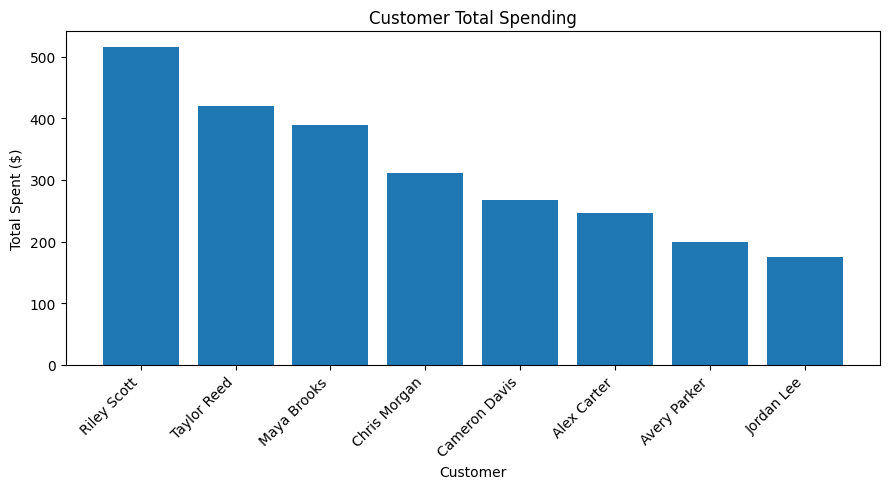

In [6]:
chart_df = pd.read_sql_query("""
SELECT name, total_spent
FROM customers
ORDER BY total_spent DESC
""", con)

plt.figure(figsize=(9, 5))
plt.bar(chart_df["name"], chart_df["total_spent"])
plt.title("Customer Total Spending")
plt.xlabel("Customer")
plt.ylabel("Total Spent ($)")
plt.xticks(rotation=45, ha="right")
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

## Takeaway

Riley Scott has the highest total spending in this customer table at $515.30. The chart uses a zero baseline and labeled axes so the spending differences are easy to read.

In [7]:
print("WHERE rows:", len(where_df))
print("ORDER BY rows:", len(order_df))
print("LIKE rows:", len(like_df))
con.close()
print("Database connection closed.")

WHERE rows: 4
ORDER BY rows: 8
LIKE rows: 2
Database connection closed.
